In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import plotly.express as px
import plotly.graph_objects as go

from math import pi

plt.style.use("ggplot")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

In [2]:
df = pd.read_csv("filled_finalAnalysis.csv")

print("Shape :", df.shape)
display(df.head(100))

Shape : (50, 25)


,question,question_type,ground_truth,vectorRAG_answer,graphRAG_answer,hybridRAG_answer,vectorRAG_sources,graphRAG_triplets,hybridRAG_sources,vector_faithfulness,...,vector_context_precision,graph_context_precision,hybrid_context_precision,vector_context_recall,graph_context_recall,hybrid_context_recall,combined_faithfulness,combined_answer_relevancy,combined_context_precision,combined_context_recall
0,What is the unique identification number (UIN)...,Basic Retrieval,The UIN of the policy is 105N153V04.,The unique identification number (UIN) of the ...,⚠️ The requested information was not found in ...,The unique identification number (UIN) of the ...,"[{""text"": ""later of Policy Issue Date or ...","[{""subject"": ""ICICI Prudential Life Insurance ...","{""vector_sources"": [{""text"": ""later of Polic...",1.000000,...,0.500000,0.0000,0.8061,1.0000,0.0000,0.9615,1.0000,1.0000,0.5000,1.0000
1,How does the policy document define 'Age' unde...,Basic Retrieval,'Age' means the age of the Life Assured in com...,"According to Part-B of the policy document, 'A...",⚠️ The requested information was not found in ...,"According to the policy document, 'Age' under ...","[{""text"": ""Policy Document - Terms and Conditi...","[{""subject"": ""Policy document"", ""subject_type""...","{""vector_sources"": [{""text"": ""Policy Document ...",0.666667,...,1.000000,0.0000,1.0000,1.0000,0.0000,0.9675,0.6667,0.8952,1.0000,1.0000
2,What is the grace period allowed for a policyh...,Basic Retrieval,A grace period of 15 days from the premium due...,The grace period allowed for a policyholder wh...,To determine the grace period allowed for a po...,The grace period allowed for a policyholder wh...,"[{""text"": ""If you are unable to pay Instalment...","[{""subject"": ""Grace Period"", ""subject_type"": ""...","{""vector_sources"": [{""text"": ""If you are unabl...",0.250000,...,1.000000,0.0000,0.7326,1.0000,0.0000,0.4642,0.2500,1.0000,1.0000,1.0000
3,Where is the physical communication address of...,Basic Retrieval,"Customer Service Desk, ICICI Prudential Life I...",The physical communication address of the ICIC...,To find the physical communication address of ...,The physical communication address of the ICIC...,"[{""text"": ""Insurance Ombudsman. We request ...","[{""subject"": ""ICICI Prudential Life Insurance ...","{""vector_sources"": [{""text"": ""Insurance Ombud...",0.333333,...,0.500000,0.6229,0.9995,1.0000,0.5085,0.9704,0.3333,1.0000,0.5000,1.0000
4,After how many years from the date of policy i...,Basic Retrieval,No policy of Life Insurance shall be called in...,A life insurance policy cannot be questioned o...,"After analyzing the knowledge graph triplets, ...",A life insurance policy cannot be questioned o...,"[{""text"": ""from a) the date of issuance of pol...","[{""subject"": ""Policy of Life Insurance"", ""subj...","{""vector_sources"": [{""text"": ""from a) the date...",0.555556,...,0.603500,0.5198,0.8353,1.0000,0.5329,0.9532,0.5556,0.8846,0.8353,1.0000
5,What are the three authorized frequencies for ...,Basic Retrieval,"The premiums can be paid in yearly, half-yearl...",The three authorized frequencies for premium p...,The three authorized frequencies for premium p...,The three authorized frequencies for premium p...,"[{""text"": ""base premium and the extra mor...","[{""subject"": ""Premiums"", ""subject_type"": ""PAYM...","{""vector_sources"": [{""text"": ""base premium a...",1.000000,...,1.000000,0.4426,0.6800,1.0000,0.4673,0.9800,1.0000,0.8493,1.0000,1.0000
6,How much does the company charge for issuing a...,Basic Retrieval,The current charge for the issuance of a dupli...,The company charges ₹ 200 for issuing a duplic...,⚠️ The requested information was not found in ...,The company charges ₹ 200 for issuing a duplic...,"[{""text"": ""charges for issuance of duplicate p...","[{""subject"": ""duplicate policy document"", ""sub...","{""vector_sources"": [{""text"": ""charges for issu...",0.333333,...,1.000000,0.0000,0.8390,1.0000,0.000

In [3]:
print(df.info())

display(df.describe())

display(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   question                    50 non-null     str    
 1   question_type               50 non-null     str    
 2   ground_truth                50 non-null     str    
 3   vectorRAG_answer            50 non-null     str    
 4   graphRAG_answer             50 non-null     str    
 5   hybridRAG_answer            50 non-null     str    
 6   vectorRAG_sources           50 non-null     str    
 7   graphRAG_triplets           50 non-null     str    
 8   hybridRAG_sources           50 non-null     str    
 9   vector_faithfulness         50 non-null     float64
 10  graph_faithfulness          50 non-null     float64
 11  hybrid_faithfulness         50 non-null     float64
 12  vector_answer_relevancy     50 non-null     float64
 13  graph_answer_relevancy      50 non-null     floa

,vector_faithfulness,graph_faithfulness,hybrid_faithfulness,vector_answer_relevancy,graph_answer_relevancy,hybrid_answer_relevancy,vector_context_precision,graph_context_precision,hybrid_context_precision,vector_context_recall,graph_context_recall,hybrid_context_recall,combined_faithfulness,combined_answer_relevancy,combined_context_precision,combined_context_recall
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,0.625011,0.151288,0.726100,0.576584,0.076128,0.605756,0.499719,0.10240,0.588634,0.900924,0.120276,0.688378,0.656972,0.682174,0.578438,0.902898
std,0.334993,0.275473,0.213809,0.393645,0.145949,0.338098,0.346304,0.19039,0.240756,0.224440,0.216610,0.255361,0.309877,0.323176,0.316571,0.220847
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.350000,0.000000,0.587600,0.208050,0.000000,0.298225,0.309800,0.00000,0.381700,1.000000,0.000000,0.507450,0.500000,0.321000,0.349025,1.000000
50%,0.633333,0.000000,0.773200,0.754849,0.000000,0.614900,0.498850,0.00000,0.639900,1.000000,0.000000,0.546650,0.666700,0.857500,0.508900,1.000000
75%,1.000000,0.000000,0.862825,0.929624,0.000000,0.926675,0.791125,0.00000,0.721525,1.000000,0.000000,0.959100,1.000000,0.931025,0.876100,1.000000
max,1.000000,0.792100,1.000000,1.000000,0.458400,1.000000,1.000000,0.62290,1.000000,1.000000,0.540200,1.000000,1.000000,1.000000,1.000000,1.000000


question                      0
question_type                 0
ground_truth                  0
vectorRAG_answer              0
graphRAG_answer               0
hybridRAG_answer              0
vectorRAG_sources             0
graphRAG_triplets             0
hybridRAG_sources             0
vector_faithfulness           0
graph_faithfulness            0
hybrid_faithfulness           0
vector_answer_relevancy       0
graph_answer_relevancy        0
hybrid_answer_relevancy       0
vector_context_precision      0
graph_context_precision       0
hybrid_context_precision      0
vector_context_recall         0
graph_context_recall          0
hybrid_context_recall         0
combined_faithfulness         0
combined_answer_relevancy     0
combined_context_precision    0
combined_context_recall       0
dtype: int64

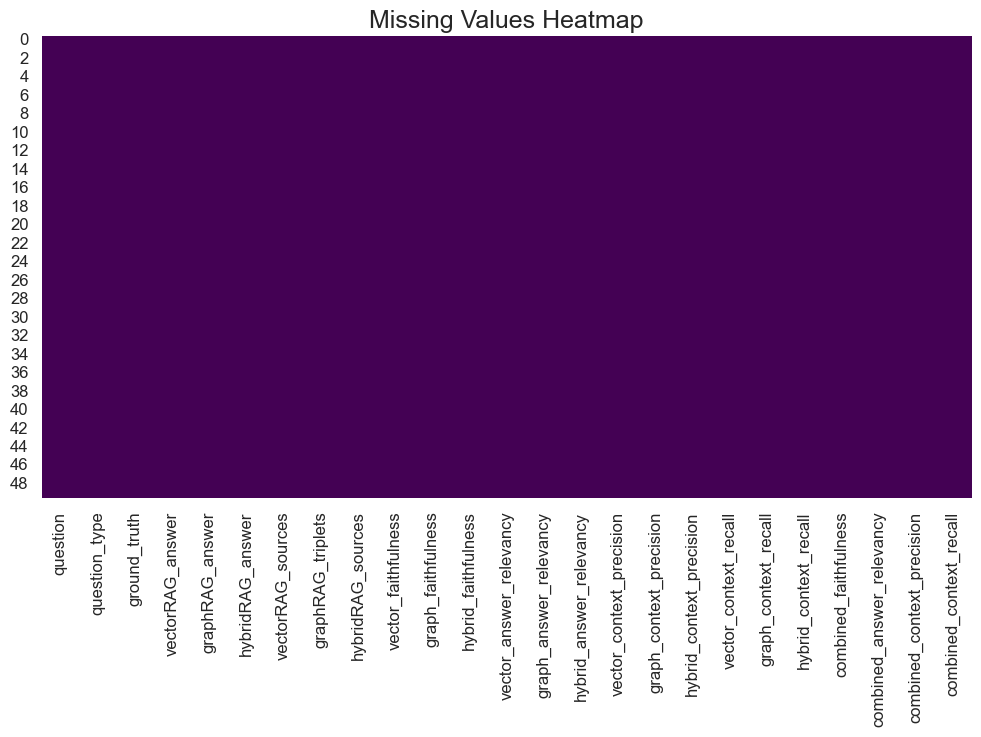

In [4]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")
plt.show()

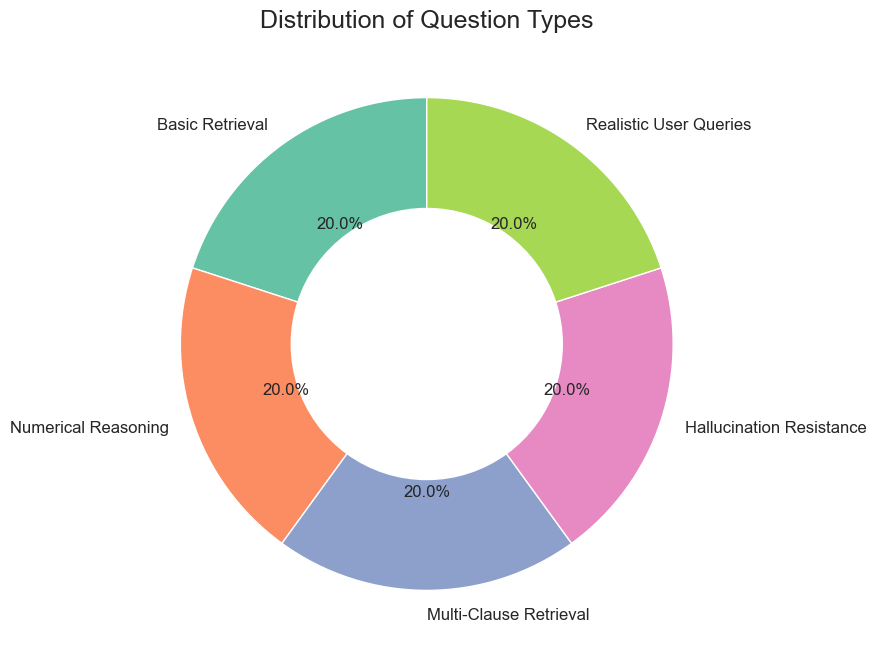

In [5]:
counts = df["question_type"].value_counts()

colors = sns.color_palette("Set2", len(counts))

plt.figure(figsize=(8,8))

plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.45)
)

plt.title("Distribution of Question Types",fontsize=18)

plt.show()

In [8]:
avg = pd.DataFrame({
    "VectorRAG":[
        df.vector_faithfulness.mean(),
        df.vector_answer_relevancy.mean(),
        df.vector_context_precision.mean(),
        df.vector_context_recall.mean()
    ],
    "GraphRAG":[
        df.graph_faithfulness.mean(),
        df.graph_answer_relevancy.mean(),
        df.graph_context_precision.mean(),
        df.graph_context_recall.mean()
    ],
    "HybridRAG":[
        df.hybrid_faithfulness.mean(),
        df.hybrid_answer_relevancy.mean(),
        df.hybrid_context_precision.mean(),
        df.hybrid_context_recall.mean()
    ],
    # "Combined":[
    #     df.combined_faithfulness.mean(),
    #     df.combined_answer_relevancy.mean(),
    #     df.combined_context_precision.mean(),
    #     df.combined_context_recall.mean()
    # ]
},
index=[
    "Faithfulness",
    "Answer Relevancy",
    "Context Precision",
    "Context Recall"
])

display(avg.round(4))

,VectorRAG,GraphRAG,HybridRAG
Faithfulness,0.6250,0.1513,0.7261
Answer Relevancy,0.5766,0.0761,0.6058
Context Precision,0.4997,0.1024,0.5886
Context Recall,0.9009,0.1203,0.6884


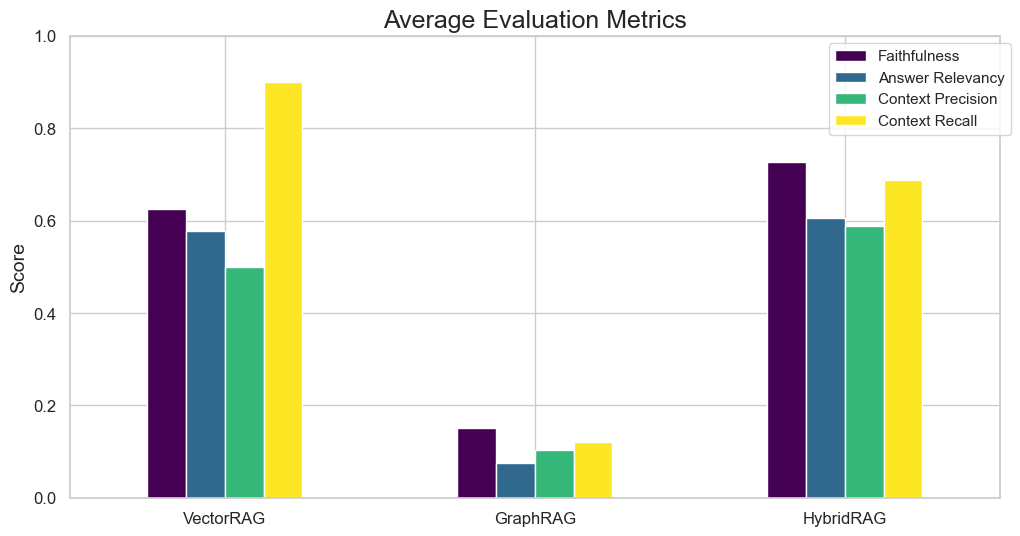

In [9]:
avg.T.plot(
    kind="bar",
    figsize=(12,6),
    colormap="viridis"
)

plt.title("Average Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0,1)

plt.xticks(rotation=0)

plt.legend(bbox_to_anchor=(1.02,1))

plt.show()

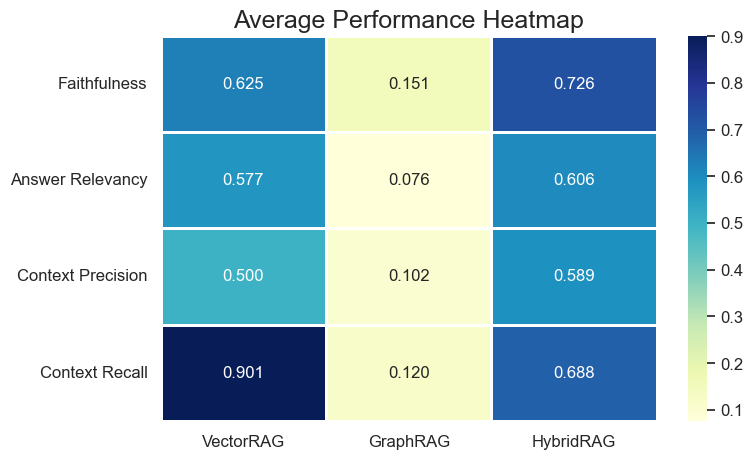

In [10]:
plt.figure(figsize=(8,5))

sns.heatmap(
    avg,
    annot=True,
    cmap="YlGnBu",
    fmt=".3f",
    linewidths=1
)

plt.title("Average Performance Heatmap")

plt.show()

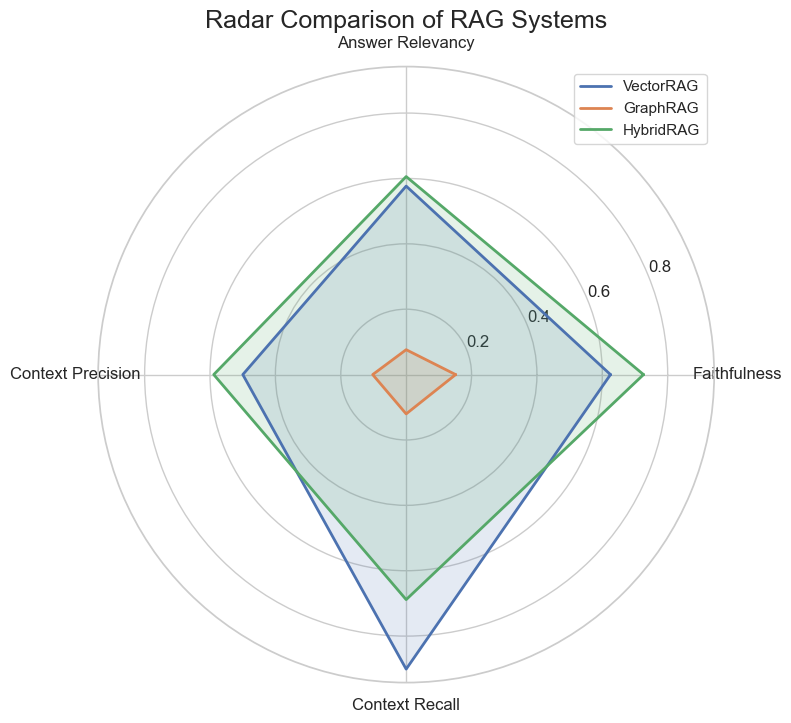

In [11]:
categories = list(avg.index)

N = len(categories)

angles = [n/float(N)*2*pi for n in range(N)]

angles += angles[:1]

fig = plt.figure(figsize=(8,8))

ax = plt.subplot(111, polar=True)

for model in avg.columns:

    values = avg[model].tolist()

    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=model
    )

    ax.fill(
        angles,
        values,
        alpha=0.15
    )

ax.set_xticks(angles[:-1])

ax.set_xticklabels(categories)

plt.legend(loc="upper right")

plt.title("Radar Comparison of RAG Systems")

plt.show()

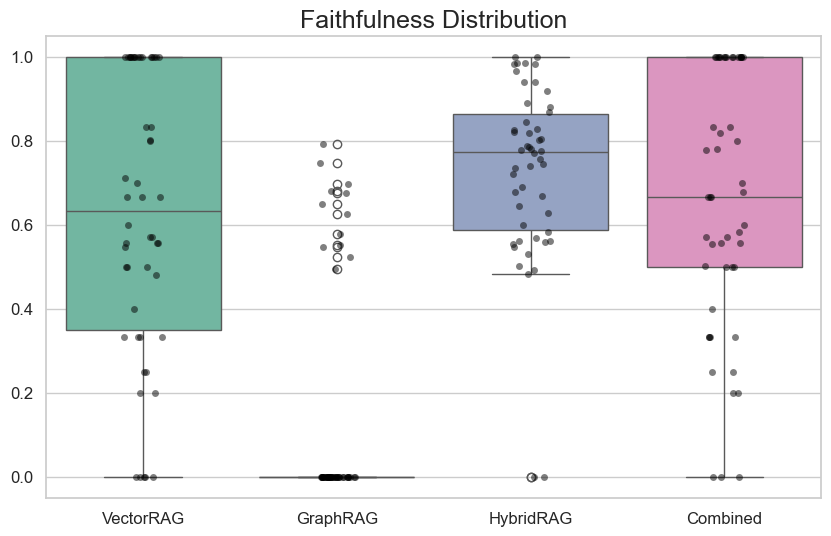

In [12]:
faith = pd.DataFrame({

"VectorRAG":df.vector_faithfulness,

"GraphRAG":df.graph_faithfulness,

"HybridRAG":df.hybrid_faithfulness,

"Combined":df.combined_faithfulness

})

plt.figure(figsize=(10,6))

sns.boxplot(data=faith,palette="Set2")

sns.stripplot(
    data=faith,
    color="black",
    alpha=0.5,
    jitter=True
)

plt.title("Faithfulness Distribution")

plt.show()

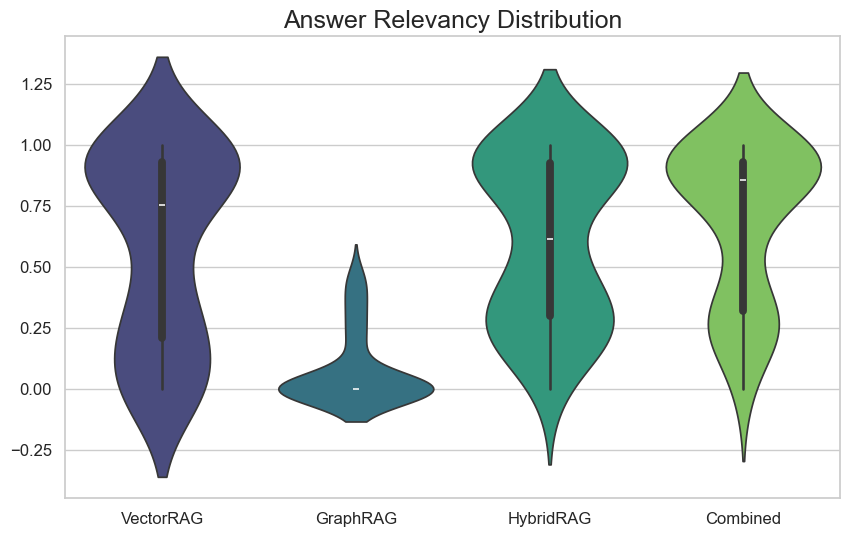

In [13]:
answer = pd.DataFrame({

"VectorRAG":df.vector_answer_relevancy,

"GraphRAG":df.graph_answer_relevancy,

"HybridRAG":df.hybrid_answer_relevancy,

"Combined":df.combined_answer_relevancy

})

plt.figure(figsize=(10,6))

sns.violinplot(
    data=answer,
    palette="viridis"
)

plt.title("Answer Relevancy Distribution")

plt.show()

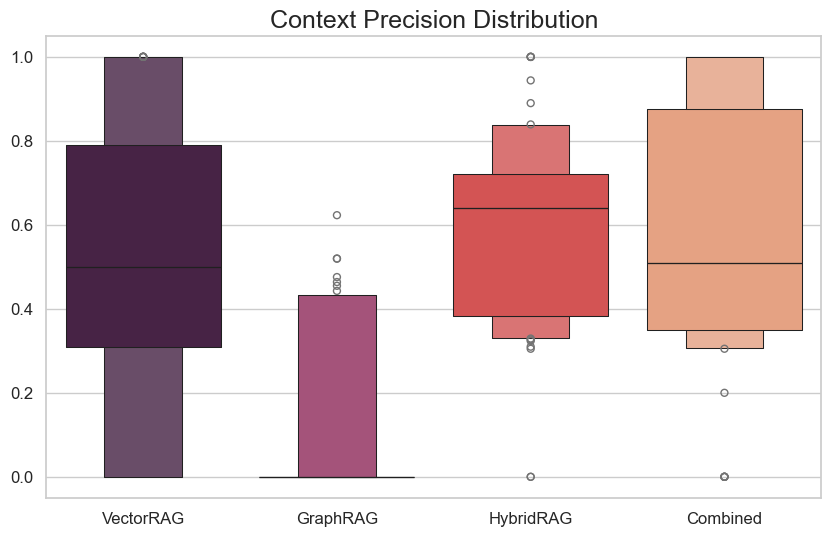

In [14]:
precision = pd.DataFrame({

"VectorRAG":df.vector_context_precision,

"GraphRAG":df.graph_context_precision,

"HybridRAG":df.hybrid_context_precision,

"Combined":df.combined_context_precision

})

plt.figure(figsize=(10,6))

sns.boxenplot(
    data=precision,
    palette="rocket"
)

plt.title("Context Precision Distribution")

plt.show()

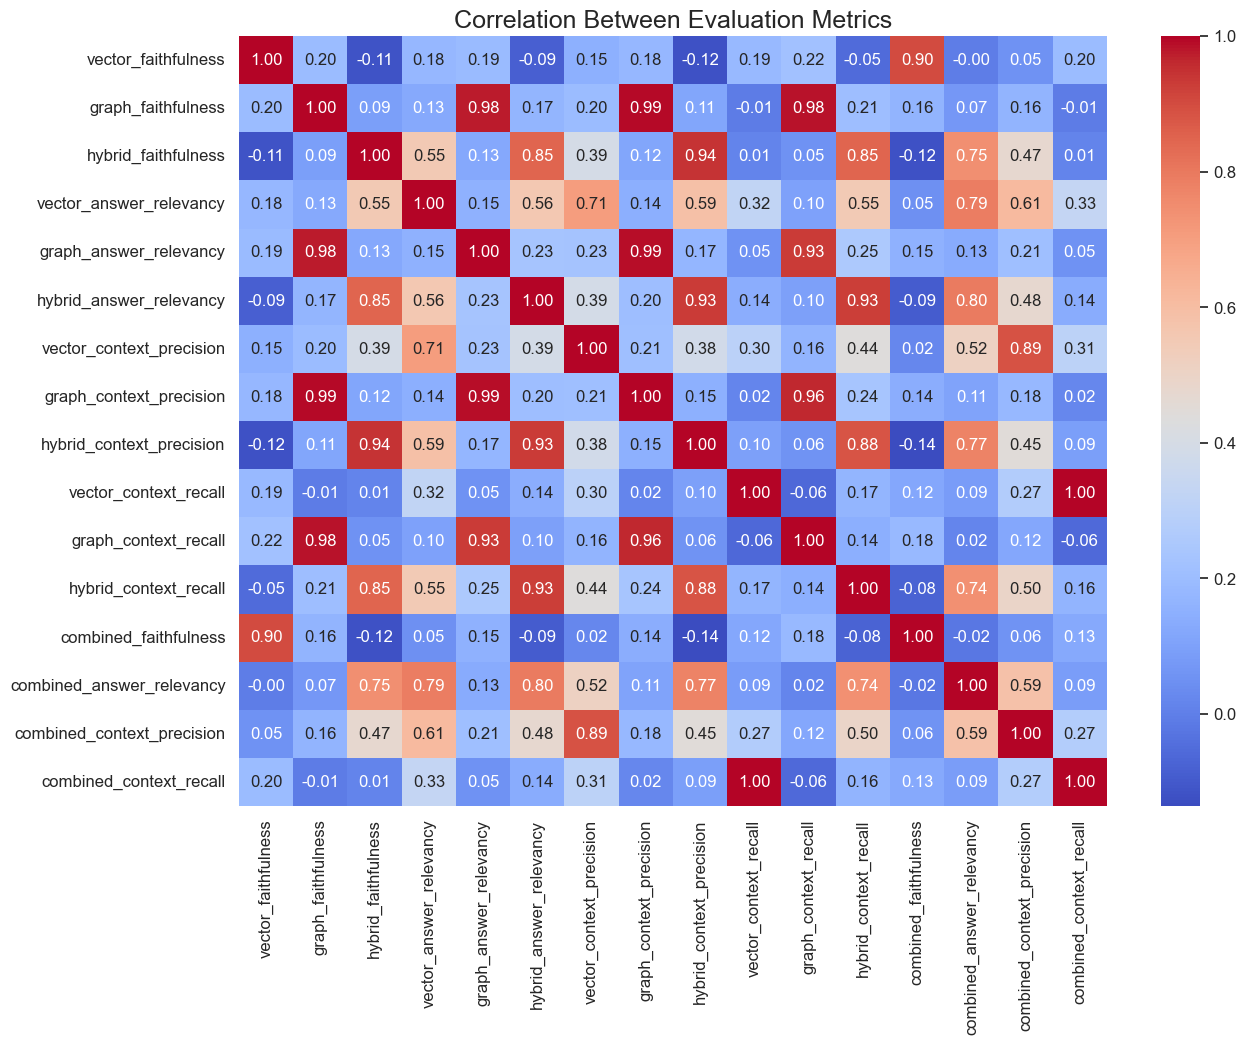

In [15]:
metric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))

sns.heatmap(
    metric_cols.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Evaluation Metrics")

plt.show()

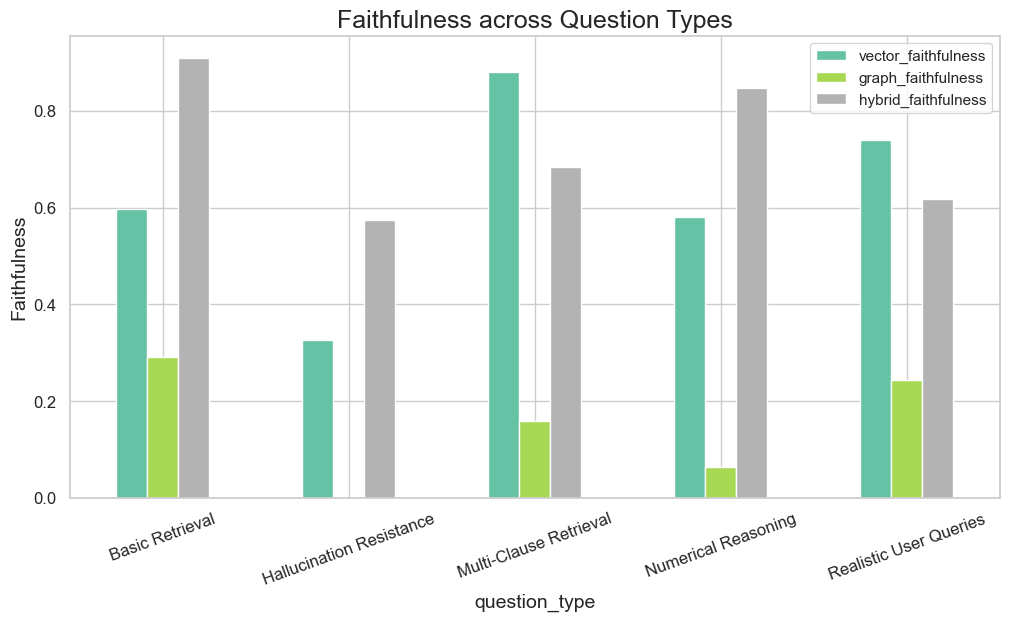

In [16]:
question_summary = df.groupby("question_type")[[
'vector_faithfulness',
'graph_faithfulness',
'hybrid_faithfulness'
]].mean()

question_summary.plot(
    kind="bar",
    figsize=(12,6),
    colormap="Set2"
)

plt.ylabel("Faithfulness")

plt.title("Faithfulness across Question Types")

plt.xticks(rotation=20)

plt.show()

In [17]:
overall = pd.Series({

"VectorRAG":
avg["VectorRAG"].mean(),

"GraphRAG":
avg["GraphRAG"].mean(),

"HybridRAG":
avg["HybridRAG"].mean(),

"Combined":
avg["Combined"].mean()

})

overall.sort_values().plot(
    kind="barh",
    color=sns.color_palette("viridis",4)
)

plt.title("Overall Average Performance")

plt.xlabel("Average Score")

plt.xlim(0,1)

plt.show()

KeyError: 'Combined'

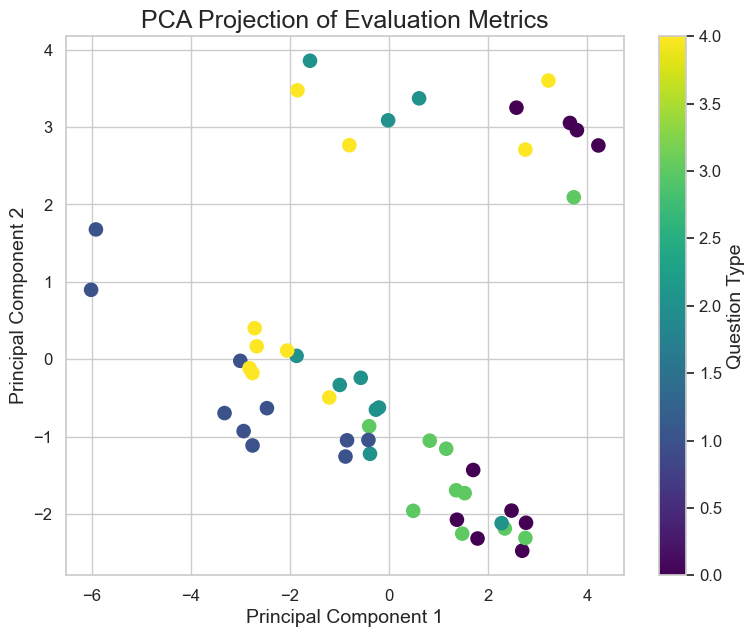

In [18]:
metrics = df[[
'vector_faithfulness',
'graph_faithfulness',
'hybrid_faithfulness',
'combined_faithfulness',

'vector_answer_relevancy',
'graph_answer_relevancy',
'hybrid_answer_relevancy',
'combined_answer_relevancy',

'vector_context_precision',
'graph_context_precision',
'hybrid_context_precision',
'combined_context_precision',

'vector_context_recall',
'graph_context_recall',
'hybrid_context_recall',
'combined_context_recall'
]]

scaled = StandardScaler().fit_transform(metrics)

pca = PCA(n_components=2)

pcs = pca.fit_transform(scaled)

plt.figure(figsize=(9,7))

plt.scatter(
    pcs[:,0],
    pcs[:,1],
    c=df.question_type.astype("category").cat.codes,
    cmap="viridis",
    s=90
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("PCA Projection of Evaluation Metrics")

plt.colorbar(label="Question Type")

plt.show()

In [19]:
parallel = avg.T.reset_index()

parallel.rename(columns={"index":"Model"},inplace=True)

fig = px.parallel_coordinates(
    parallel,
    color="Faithfulness",
    dimensions=[
        "Faithfulness",
        "Answer Relevancy",
        "Context Precision",
        "Context Recall"
    ],
    color_continuous_scale=px.colors.sequential.Viridis
)

fig.show()

In [24]:
import pandas as pd

# Load dataset
df = pd.read_csv("analysis3.csv")

# Compute average metrics (NaN values are ignored automatically)
table = pd.DataFrame({
    "Metric": [
        "Faithfulness",
        "Answer Relevancy",
        "Context Precision",
        "Context Recall"
    ],
    "VectorRAG": [
        df["vector_faithfulness"].mean(),
        df["vector_answer_relevancy"].mean(),
        df["vector_context_precision"].mean(),
        df["vector_context_recall"].mean()
    ],
    "GraphRAG": [
        df["graph_faithfulness"].mean(),
        df["graph_answer_relevancy"].mean(),
        df["graph_context_precision"].mean(),
        df["graph_context_recall"].mean()
    ],
    "HybridRAG": [
        df["hybrid_faithfulness"].mean(),
        df["hybrid_answer_relevancy"].mean(),
        df["hybrid_context_precision"].mean(),
        df["hybrid_context_recall"].mean()
    ]
})
print("Analysis 3")
table


Analysis 3


,Metric,VectorRAG,GraphRAG,HybridRAG
0,Faithfulness,0.625011,0.151288,0.726100
1,Answer Relevancy,0.576584,0.076128,0.605756
2,Context Precision,0.499719,0.102400,0.588634
3,Context Recall,0.900924,0.120276,0.688378
